# Shap and FAR synthetic data tests

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbimporter
import sklearn.ensemble
import xgboost as xgb
import shap

import synthetic_data as syn
import Ft_Att_Rank as far

# Load synthetic dataset

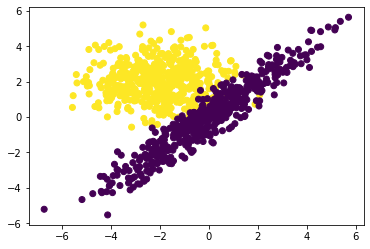

In [4]:
synth= syn.synthetic_data_generator(n=500,df=True)

X= synth.to_numpy()

plt.scatter(X[:,0],X[:,1],c=X[:,-1])

In [127]:
# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

#x_syn= far.normalize_selected_cols(x_syn, x_syn.columns)

In [128]:
x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-2.849034,2.650111,2.994049,3.690806
1,-2.096237,2.043051,2.567796,3.342552
2,-2.565710,1.668455,1.102789,3.948374
3,-1.913146,2.973977,-0.984353,-3.446639
4,-0.928584,3.758939,-1.602152,3.760544


# ML model setup

In [129]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,train_size=0.80,
                                                                                 random_state=1234)

In [130]:
# Creates and train ML model - XGBoost random forest
xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')

xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


0.96

In [131]:
# Creates and train ML model - Random forest
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)

rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.96

# Shap test

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


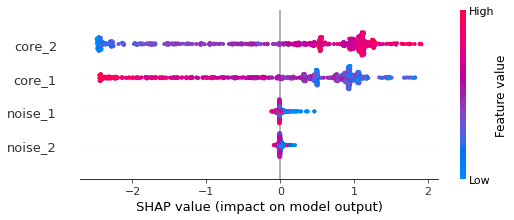

In [133]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [134]:
shap_values[1]

.values =
array([ 1.0668234e+00,  9.5056909e-01, -4.4448557e-03,  6.6071335e-04],
      dtype=float32)

.base_values =
-0.019608593

.data =
array([-1.90838893,  1.14720979, -0.80522999,  3.53392042])

In [138]:
train.head()

,core_1,core_2,noise_1,noise_2
281,-2.053608,1.334657,-3.112663,-2.159213
42,-1.908389,1.147210,-0.805230,3.533920
255,1.368627,2.364007,-3.110239,1.521004
906,-4.072302,-3.905722,1.028066,2.882294
394,-2.324634,-0.420052,-3.026808,-3.265302


In [139]:
labels_train.head()

,target
281,1.0
42,1.0
255,1.0
906,0.0
394,1.0


# FAR test - Global version with no retraining

In [141]:
num_fts= len(x_syn.columns)

replace_ft= far.replace_values(x_syn, x_syn.columns, num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft, test, labels_test, verbose=True)

--- 0.15 seconds ---


In [142]:
acc_all_fts= xgb_acc

# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [143]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    5.551115e-17
noise_2    5.551115e-17
dtype: float64

In [144]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.256375
core_2     0.255451
noise_1    0.214632
noise_2    0.214632
dtype: float64

In [145]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.249330
core_2     0.248838
noise_2    0.220104
noise_1    0.220104
dtype: float64

In [146]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    5.551115e-17
noise_2    5.551115e-17
dtype: float64

# FAR test - PageRank Global version with no retraining

In [147]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= far.p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.p_matrix_to_row_stochastic_matrix(p_matrix4)

In [148]:
# using networkx lib

In [149]:
far.run_lib_pr(st_matrix1, x_syn.columns)

core_1     0.463618
core_2     0.461382
noise_1    0.037500
noise_2    0.037500
dtype: float64

In [150]:
far.run_lib_pr(st_matrix2, x_syn.columns)

noise_1    0.271109
noise_2    0.271109
core_1     0.229395
core_2     0.228387
dtype: float64

In [151]:
far.run_lib_pr(st_matrix3, x_syn.columns)

noise_1    0.275948
noise_2    0.275948
core_1     0.224327
core_2     0.223778
dtype: float64

In [152]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_1     0.463618
core_2     0.461382
noise_1    0.037500
noise_2    0.037500
dtype: float64

In [153]:
# using my PageRank lib

In [154]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.565290
core_2     0.293473
noise_1    0.070618
noise_2    0.070618
dtype: float64

In [155]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_1     0.396822
noise_1    0.203194
noise_2    0.203194
core_2     0.196791
dtype: float64

In [156]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.387454
noise_1    0.207814
noise_2    0.207814
core_2     0.196918
dtype: float64

In [157]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.565290
core_2     0.293473
noise_1    0.070618
noise_2    0.070618
dtype: float64

# FAR test - Local version - data and target

In [186]:
# the instance to be explained (from train dataset)
target_pos= 1

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

#replace_ft[x_syn.columns]= 0

# FAR test - Local version with no retraining

In [121]:
num_fts= len(x_syn.columns)

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft, target_inst, target_labl, verbose=True)

--- 0.13 seconds ---


In [188]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [190]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    5.551115e-17
noise_2    5.551115e-17
dtype: float64

In [191]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.256375
core_2     0.255451
noise_1    0.214632
noise_2    0.214632
dtype: float64

In [192]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.249330
core_2     0.248838
noise_2    0.220104
noise_1    0.220104
dtype: float64

In [193]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    5.551115e-17
noise_2    5.551115e-17
dtype: float64

# FAR test - Knn-only local version

In [210]:
# neighborhood with similar elements, i.e., only instances from the same class of target instance

neigh_lb_test= labels_test[labels_test.target== target_labl.iloc[0,0]]

neigh_ft_test= test.loc[neigh_lb_test.index]

In [221]:
acc_no_i, acc_no_ij= far.knn_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test, 
                                                     target_inst, target_labl, neighb_size= 0.3, verbose=True)

--- 0.13 seconds ---


In [222]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [223]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    5.551115e-17
noise_2    5.551115e-17
dtype: float64

In [224]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.292151
core_2     0.254360
noise_2    0.200581
noise_1    0.200581
dtype: float64

In [225]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.292808
core_2     0.250000
noise_2    0.228596
noise_1    0.228596
dtype: float64

In [226]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.382363
core_2     0.340788
noise_1    0.138425
noise_2    0.138425
dtype: float64

# FAR test - KnnFold local version

In [233]:
acc_no_i, acc_no_ij= far.knnfold_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test,
                                                         target_inst, target_labl, neighb_size= 0.5, k_folds=10,
                                                         verbose=True)

--- 0.8 seconds ---


In [234]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [235]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.5
core_2     0.5
noise_1    0.0
noise_2    0.0
dtype: float64

In [236]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.499399
core_2     0.499399
noise_1    0.000601
noise_2    0.000601
dtype: float64

In [237]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.314347
core_1     0.314347
noise_1    0.185653
noise_2    0.185653
dtype: float64

In [238]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.314347
core_1     0.314347
noise_1    0.185653
noise_2    0.185653
dtype: float64

# FAR test - KnnFold local version PageRank

In [239]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# converts a matrix to a row stochastic matrix
st_matrix1= far.to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.to_row_stochastic_matrix(p_matrix4)

In [240]:
# using networkx lib

In [241]:
far.run_lib_pr(st_matrix1, x_syn.columns)

core_2     0.4625
core_1     0.4625
noise_1    0.0375
noise_2    0.0375
dtype: float64

In [242]:
far.run_lib_pr(st_matrix2, x_syn.columns)

core_1     0.434011
core_2     0.434011
noise_1    0.065989
noise_2    0.065989
dtype: float64

In [243]:
far.run_lib_pr(st_matrix3, x_syn.columns)

core_1     0.305166
core_2     0.305166
noise_2    0.194834
noise_1    0.194834
dtype: float64

In [244]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_1     0.305166
core_2     0.305166
noise_2    0.194834
noise_1    0.194834
dtype: float64

In [245]:
# using my PageRank lib

In [246]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.561766
core_2     0.297628
noise_1    0.070303
noise_2    0.070303
dtype: float64

In [247]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_1     0.559687
core_2     0.235206
noise_1    0.102554
noise_2    0.102554
dtype: float64

In [248]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.442116
core_2     0.272436
noise_1    0.164650
noise_2    0.120799
dtype: float64

In [249]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.442116
core_2     0.272436
noise_1    0.164650
noise_2    0.120799
dtype: float64

# FAR test - Global version with retraining

In [250]:
repeat_train= 5

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train, labels_test,repeat_train)

acc_no_i, acc_no_ij= far.remove_and_retrain(xgb_model, replace_ft, train, test, labels_train,
                                               labels_test,repeat_train,verbose=True)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


--- 39.21 seconds ---


In [251]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [252]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.486562
core_1     0.475109
noise_1    0.022808
noise_2    0.015521
dtype: float64

In [253]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.385575
core_1     0.261031
noise_1    0.178644
noise_2    0.174750
dtype: float64

In [254]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.380260
core_1     0.244925
noise_1    0.188521
noise_2    0.186294
dtype: float64

In [255]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.491169
core_1     0.483839
noise_1    0.014884
noise_2    0.010109
dtype: float64